In [ ]:
import networkx as nx
import pandas as pd # version 2.3.1 installed cocurrenlty with skmob
import geopandas as gpd #1.0.1
import numpy as np # 2.2.6
import shapely   # 2.0.7 , measure importance of features through SHAP values
import os
import skmob
import dropbox
import os
from dotenv import load_dotenv 
from dropbox import DropboxOAuth2FlowNoRedirect

In [ ]:
def authorize():
    load_dotenv()
    APP_KEY = os.environ.get("DROPBOX_APP_KEY")
    APP_SECRET = os.environ.get("DROPBOX_APP_SECRET")

    auth_flow = DropboxOAuth2FlowNoRedirect(APP_KEY,
                                            use_pkce = True,
                                            consumer_secret=APP_SECRET,
                                            token_access_type='offline',
                                            scope=['files.content.read'])

    authorize_url = auth_flow.start()
    print("1. Go to: " + authorize_url)
    print("2. Click \"Allow\" (you might have to log in first).")
    print("3. Copy the authorization code.")
    auth_code = input("Enter the authorization code here: ").strip()

    try:
        oauth_result = auth_flow.finish(auth_code)
        assert oauth_result.scope == 'files.content.read files.metadata.read'
    except Exception as e:
        print('Error: %s' % (e,))
        print(oauth_result.scope)
        exit(1)

    with dropbox.Dropbox(oauth2_access_token=oauth_result.access_token,
                        oauth2_access_token_expiration=oauth_result.expires_at,
                        oauth2_refresh_token=oauth_result.refresh_token,
                        app_key=APP_KEY,
                        app_secret=APP_SECRET) as dbx:        
        print("Successfully set up client!")
        return dbx

In [19]:
dbx = authorize()

1. Go to: https://www.dropbox.com/oauth2/authorize?response_type=code&client_id=vbt4c90yghbwqpt&token_access_type=offline&code_challenge=13n8sUpwvOwZf8Gs08Gm19OcKTMd8pE2tF6zQQPmmvY&code_challenge_method=S256&scope=files.content.read
2. Click "Allow" (you might have to log in first).
3. Copy the authorization code.
Error: 
files.content.read files.metadata.read
Successfully set up client!


In [ ]:
from io import BytesIO

In [ ]:
def load_data(dbx: dropbox.Dropbox, data_folder_path:str) -> tuple:
    """
    Returns:
        A tuple containing:
        - A dictionary with keys being each state code and values being the original datasets for that state with columns
        "Otract", "Dtract", "EST"
        - Ditto, but the dataset contains the columns "Id", "Jobs", "Pop" 
    """
    datasets = {}
    data_folder = dbx.files_list_folder(data_folder_path)
    for file in data_folder.entries:
        # file.name.split("_") creates list of items split from the filename -> [-1] access last item -> .split(".") splits last item by "."-> [0] accesses the first item which is the state code
        state_code = file.name.split("_")[-1].split(".")[0]
        file_path = os.path.join(data_folder_path, file.name)
        metaData, data = dbx.files_download(file_path)
        df = pd.read_csv(BytesIO(data.content))
        # Add the DataFrame to the container with the state code as the label
        datasets[state_code] = df
    dbx.close()

    dsets_grouped = {}
    for state_code, df in datasets.items():
        grouped = pd.DataFrame()
        # no_jobs is a datafram of tracts that have a resident population, but don't provide any jobs for commuting workers from other census tracts
        no_jobs = pd.DataFrame(set(df['Otract'].unique()) - set(df['Dtract'].unique()), columns = ['Id'])
        # no_pop is a data frame of tracts that provide jobs,  but do not have any resident population
        no_pop = pd.DataFrame(set(df['Dtract'].unique()) - set(df['Otract'].unique()), columns = ['Id'])
        
        grouped = pd.DataFrame(set(df['Otract'].unique()).union(set(df['Dtract'].unique())), 
                        columns = ["Id"])
        jobs = df.groupby('Dtract')['EST'].sum()
        grouped['Jobs'] = grouped['Id'].map(jobs)
        grouped['Jobs'] = grouped['Jobs'].fillna(0).astype(int)
        pop = df.groupby('Otract')['EST'].sum()
        grouped['Pop'] = grouped['Id'].map(pop)
        grouped['Pop'] = grouped['Pop'].fillna(0).astype(int)
        dsets_grouped[state_code] = grouped
    assert not dsets_grouped['FL'].isna().values.any() and not datasets['FL'].isna().values.any()
    return datasets, dsets_grouped

In [ ]:
datasets, dsets_grouped = load_data(dbx, "/Mobility Prediction/data/ctpp/2017-2021")

# Traditional gravity model

In [3]:
from skmob.utils import utils, constants
from skmob.models import gravity    

In [ ]:
url_tess = skmob.utils.constants.NY_COUNTIES_2011
tessellation = gpd.read_file(url_tess).rename(columns={'tile_id': 'tile_ID'})

In [ ]:
tessellation.head()

,tile_ID,population,geometry
0,36019,81716,"POLYGON ((-74.00667 44.88602, -74.02739 44.995..."
1,36101,99145,"POLYGON ((-77.09975 42.27421, -77.09966 42.272..."
2,36107,50872,"POLYGON ((-76.25015 42.29668, -76.24914 42.302..."
3,36059,1346176,"POLYGON ((-73.70766 40.72783, -73.70027 40.739..."
4,36011,79693,"POLYGON ((-76.27907 42.78587, -76.27535 42.780..."


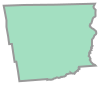

In [ ]:
tessellation['geometry'][0]

Tessellation is a geodataframe containing geometry represented as a GeoSeries.

In [ ]:
type(tessellation)

geopandas.geodataframe.GeoDataFrame

In [ ]:
type(tessellation['geometry'][0])

shapely.geometry.polygon.Polygon

In [ ]:
print(tessellation['geometry'][0].wkt, '\n')
print(tessellation['geometry'][0].boundary, '\n') # represents exterior of the shape, takes same values as wkt
print(tessellation['geometry'][0].area, '\n')
print(tessellation.crs)

POLYGON ((-74.006668 44.886017, -74.027389 44.995685, -73.87459699999999 45.001223, -73.639718 45.003464, -73.343124 45.01084, -73.35463300000001 44.987352, -73.350218 44.976222, -73.338244 44.964751, -73.339603 44.943371, -73.33897899999999 44.917681, -73.341106 44.914632, -73.350652 44.909634, -73.356218 44.904492, -73.360328 44.897236, -73.36910399999999 44.866681, -73.371968 44.862415, -73.379822 44.857038, -73.37954499999999 44.851651, -73.38159 44.849354, -73.380321 44.847173, -73.381336 44.844683, -73.379447 44.843461, -73.379452 44.83801, -73.37534599999999 44.836307, -73.368275 44.828007, -73.353472 44.820386, -73.335044 44.804109, -73.33315399999999 44.788759, -73.335713 44.782086, -73.34708500000001 44.77298, -73.354361 44.755296, -73.365562 44.741786, -73.365977 44.697559, -73.36130799999999 44.694524, -73.365297 44.687548, -73.370142 44.684855, -73.367209 44.678514, -73.371843 44.676957, -73.37101 44.672763, -73.372719 44.668739, -73.369668 44.663478, -73.374577 44.66189, 

In [ ]:
tessellation.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - NAD83
- bounds: (167.65, 14.92, -47.74, 86.46)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

'Jobs' represents the inflows of a census tract (number of workers commuting to the tract for work). 'Pop' represents the outflows of a census tract (number of workers residing in the tract that leave to work in a different tract).

We need a spatial tesselation and a FlowDataFrame to generate the gravity model. The spatial tessellation structure can be found by navigating to <venv_path>/lib/Python3.9/site-packages/skmob/utils/constants

In [ ]:
import pyogrio; pyogrio.list_drivers()
import fiona
fiona.supported_drivers

{'PCIDSK': 'rw',
 'PDS4': 'rw',
 'VICAR': 'rw',
 'PDF': 'rw',
 'MBTiles': 'rw',
 'EEDA': 'r',
 'OGCAPI': 'r',
 'ESRI Shapefile': 'rw',
 'MapInfo File': 'rw',
 'UK .NTF': 'r',
 'LVBAG': 'r',
 'OGR_SDTS': 'r',
 'S57': 'rw',
 'DGN': 'rw',
 'OGR_VRT': 'r',
 'Memory': 'rw',
 'CSV': 'rw',
 'GML': 'rw',
 'GPX': 'rw',
 'KML': 'rw',
 'GeoJSON': 'rw',
 'GeoJSONSeq': 'rw',
 'ESRIJSON': 'r',
 'TopoJSON': 'r',
 'OGR_GMT': 'rw',
 'GPKG': 'rw',
 'SQLite': 'rw',
 'WAsP': 'rw',
 'OpenFileGDB': 'rw',
 'DXF': 'rw',
 'FlatGeobuf': 'rw',
 'Geoconcept': 'rw',
 'GeoRSS': 'rw',
 'VFK': 'r',
 'PGDUMP': 'rw',
 'OSM': 'r',
 'GPSBabel': 'rw',
 'OGR_PDS': 'r',
 'WFS': 'r',
 'OAPIF': 'r',
 'EDIGEO': 'r',
 'SVG': 'r',
 'Idrisi': 'r',
 'ODS': 'rw',
 'XLSX': 'rw',
 'Elasticsearch': 'rw',
 'Carto': 'rw',
 'AmigoCloud': 'rw',
 'SXF': 'r',
 'Selafin': 'rw',
 'JML': 'rw',
 'PLSCENES': 'r',
 'CSW': 'r',
 'VDV': 'rw',
 'MVT': 'rw',
 'NGW': 'rw',
 'MapML': 'rw',
 'GTFS': 'r',
 'PMTiles': 'rw',
 'JSONFG': 'rw',
 'MiraMonVecto

In [ ]:
# Upgrade geopandas from the version installed along skmob  
# %pip install --upgrade geopandas fiona

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.5/27.5 MB 11.1 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 12.0 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: pyproj
    Found existing installation: pyproj 2.6.1.post1
    Uninstalling pyproj-2.6.1.post1:
      Successfully uninstalled pyproj-2.6.1.post1
  Attempting uninstall: pyogrio━━━━━━━━━━━━━━━━━ 0/3 [pyproj]
    Found existing installation: pyogrio 0.5.10m 0/3 [pyproj]
    Uninstalling pyogrio-0.5.1:━━━━━━━━━━━━━ 0/3 [pyproj]
      Successfully uninstalled pyogrio-0.5.1 0/3 [pyproj]
  Attempting uninstall: geopandas0m━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [pyogrio]
    Found existing installation: geopandas 0.12.2━━━━━━━━━━━━━ 1/3 [pyogrio]
    Uninstalling geopandas-0.12.2:0m━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [pyogrio]
      Successfully uninstalled geopandas-0.12.2━━━━━━━━━━━━━━━ 1/3 [pyogrio]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [geopandas]/3 [geopandas]
ERROR: pip's dependency resolver d

In [6]:
fl_tessellation = gpd.read_file("../data/FL_2020.gdb", layer = 'ACS_2020_5YR_TRACT_12_FLORIDA')

In [ ]:
dsets_grouped['FL'].head()

,Id,Jobs,Pop
0,36071014400,25,0
1,12071010305,482,1628
2,12011110402,945,2337
3,12011110403,329,1853
4,12011110404,354,2120


In [9]:
# fl_tessellation.head()
fl_tessellation.columns

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'NAME', 'NAMELSAD', 'MTFCC',
       'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'Shape_Length',
       'Shape_Area', 'GEOID_Data', 'geometry'],
      dtype='object')

Join fl_tesselation with dsets_grouped['Fl'] based on the tract Id column

In [11]:
fl_tessellation.GEOID

0       12011110403
1       12011060114
2       12011060120
3       12011110347
4       12011020421
           ...     
5155    12015020700
5156    12005001900
5157    12005000600
5158    12005000500
5159    12015010200
Name: GEOID, Length: 5160, dtype: object

In [13]:
fl_joined = pd.concat([fl_tessellation.GEOID, dsets_grouped['FL'].Id])

NameError: name 'dsets_grouped' is not defined

AttributeError: 'DataFrame' object has no attribute 'geometry'

In [ ]:
flows_ex = skmob.utils.constants.NY_FLOWS_2011 #https://raw.githubusercontent.com/scikit-mobility/scikit-mobility/master/examples/NY_commuting_flows_2011.csv
flows_ex = pd.read_csv(flows_ex)

In [ ]:
flows_ex.head()

,flow,origin,destination
0,121606,36001,36001
1,5,36001,36005
2,29,36001,36007
3,11,36001,36017
4,30,36001,36019


In [ ]:
datasets['FL'].head()

,Otract,Dtract,EST
0,12001000201,12001000201,405.0
1,12001000201,12001000202,40.0
2,12001000201,12001000301,20.0
3,12001000201,12001000400,225.0
4,12001000201,12001000500,35.0
